In [1]:
import os
import pandas as pd

ruta_base = "C:/Users/USER/Documents/Trabajo/Cedulas/Rotacion/No_angulo"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label,"Angle":0.0})

# Crear el DataFrame
df = pd.DataFrame(data)
df['Label_decode'], uniques = pd.factorize(df["Label"])
stratiffy=[i for i in uniques]
print(df.head())
df.to_excel("df_oritation.xlsx")


                                                Path      Label  Angle  \
0  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo    0.0   
1  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo    0.0   
2  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo    0.0   
3  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo    0.0   
4  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo    0.0   

   Label_decode  
0             0  
1             0  
2             0  
3             0  
4             0  


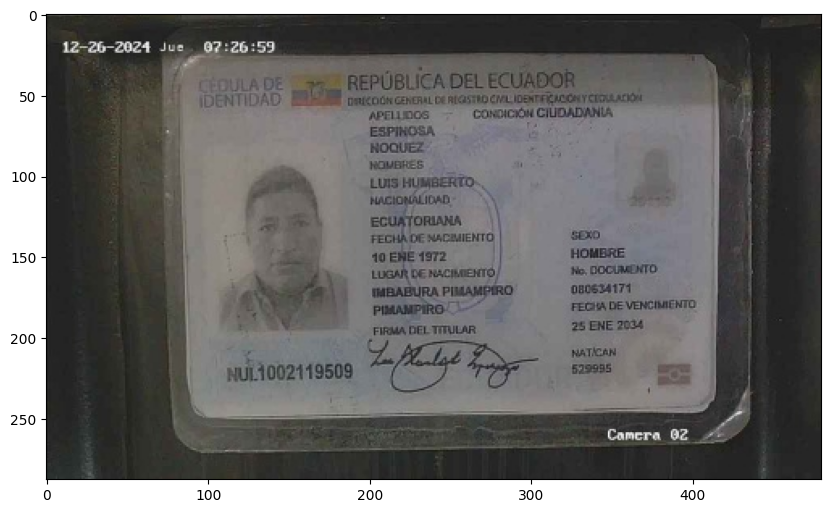

Ángulo estimado: 67.44°


In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
def detectar_angulo(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Binarización adaptativa
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    
    # Contornos
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    angles = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 100:
            continue
        rect = cv2.minAreaRect(cnt)
        angle = rect[-1]
        if angle < -45:
            angle = 90 + angle
        angles.append(angle)
    
    if angles:
        return np.mean(angles)
    return 0

# Cargar imagen
img = cv2.imread(df["Path"][0])
img_show=Image.fromarray(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.show()
angulo = detectar_angulo(img)
print(f"Ángulo estimado: {angulo:.2f}°")


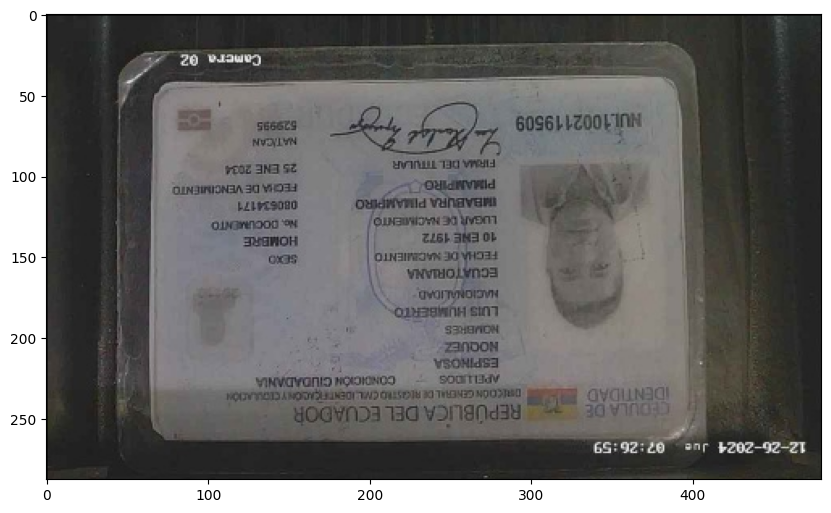

In [3]:
import cv2

escala=1
# Obtener dimensiones
(h, w) = img.shape[:2]
centro = (w // 2, h // 2)

# Crear la matriz de rotación: ángulo en grados y escala
M = cv2.getRotationMatrix2D(centro, -180, escala)

# Aplicar la rotación
imagen_rotada = cv2.warpAffine(img, M, (w, h))

img_show=Image.fromarray(cv2.cvtColor(imagen_rotada,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.show()


In [4]:
import random
random.seed(42)

df_rot=df.sample(n=20,random_state=42)
df_rot["Angle"]=df_rot["Angle"].apply(lambda x:-random.uniform(1,360))
print(df_rot.head())

                                                  Path      Label       Angle  \
73   C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo -230.554221   
218  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo   -9.978861   
25   C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo  -99.735525   
208  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo  -81.132655   
9    C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  No_angulo -265.393166   

     Label_decode  
73              0  
218             0  
25              0  
208             0  
9               0  


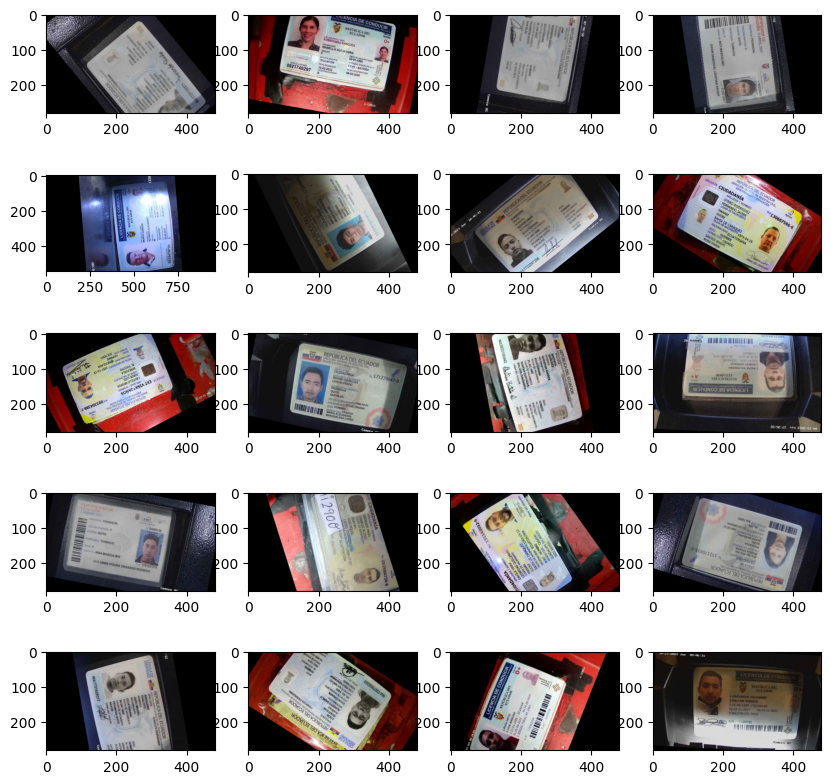

In [5]:
fig , axes = plt.subplots(ncols=4,nrows=5,figsize=(10,10))
axes=axes.flatten()
i=0
for index, d_f in df_rot.iterrows():
    img = cv2.imread(d_f["Path"])
    (h, w) = img.shape[:2]
    centro = (w // 2, h // 2)

    # Crear la matriz de rotación: ángulo en grados y escala
    M = cv2.getRotationMatrix2D(centro, d_f["Angle"], escala)

    # Aplicar la rotación
    imagen_rotada = cv2.warpAffine(img, M, (w, h))
    img_show=Image.fromarray(cv2.cvtColor(imagen_rotada,cv2.COLOR_BGR2RGB))
    axes[i].imshow(img_show)
    i+=1


In [6]:
porc=int(len(df)*0.7)
df_rot=df.sample(n=porc,random_state=42)
df_rot["Angle"]=df_rot["Angle"].apply(lambda x:-random.uniform(1,360))
df=df.drop(columns=["Label","Label_decode"])
df.update(df_rot)




(1280,)
                                                Path       Angle  \
0  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci... -269.523226   
1  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...    0.000000   
2  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci... -153.064726   
3  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci... -279.583968   
4  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...    0.000000   

                                             Vectors  
0  [0.0, 0.0, 0.7275832, 0.044533655, 0.016643096...  
1  [0.30725482, 0.0, 0.15535848, 0.1034967, 0.022...  
2  [0.0, 0.0, 0.0027769925, 0.33215255, 0.1338407...  
3  [0.0, 0.0, 0.5629058, 0.05863164, 0.039993275,...  
4  [0.06969297, 0.0, 0.6218581, 0.0, 0.0, 0.0, 0....  


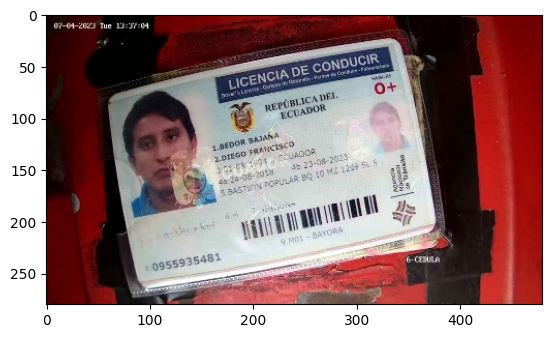

In [7]:
import torch
from torchvision import models, transforms
import torch.nn as nn
import cv2

# 1. Modelo MobileNetV2 con avgpool
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V2")
feature_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # ↓ reduce a (batch_size, 1280, 1, 1)
)
feature_extractor.eval()

# 2. Preprocesamiento estándar (IMAGENET compatible)
preprocess = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # mejor usar valores de imagenet
                             std=[0.229, 0.224, 0.225]),
    ]
)

# 3. Extraer vectores
features_list = []
labels_list = []

def extract_feature_vector(image_path: str,angulo) -> torch.Tensor:
    """
    Extrae un vector de características de tamaño (1280,) de una imagen usando MobileNetV2.

    Args:
        image_path (str): Ruta al archivo de imagen.

    Returns:
        np.ndarray: Vector de características de tamaño (1280,) o None si hay error.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"[WARNING] No se pudo cargar la imagen: {image_path}")
        return None
    (h, w) = img_bgr.shape[:2]
    centro = (w // 2, h // 2)

    # Crear la matriz de rotación: ángulo en grados y escala
    M = cv2.getRotationMatrix2D(centro, angulo, escala)

    # Aplicar la rotación
    imagen_rotada = cv2.warpAffine(img_bgr, M, (w, h))

    img_rgb = cv2.cvtColor(imagen_rotada, cv2.COLOR_BGR2RGB)
    img_show=Image.fromarray(img_rgb)
    plt.imshow(img_show)
    input_tensor = preprocess(img_rgb).unsqueeze(0)

    with torch.no_grad():
        features = feature_extractor(input_tensor)
        vector = features.view(-1).numpy()  # → shape: (1280,)
    
    return vector
features_list=[]
for i, row in df.iterrows():
    image_pros=extract_feature_vector(row["Path"],row["Angle"])
    features_list.append(image_pros)

print(features_list[0].shape)
df["Vectors"]=features_list

print(df.head())

In [8]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import lightning as L
from sklearn.model_selection import train_test_split, KFold


class MyDataModule(L.LightningDataModule):
    def __init__(self, X, y, batch_size=64, clases=1, kfold=2):
        super().__init__()
        self.batch_size = batch_size
        self.num_classes = clases
        self.kfold = kfold
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.folder = KFold(n_splits=kfold, shuffle=True, random_state=42)

    def prepare_data(self):
        # Split data once
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=0.3,
            random_state=42,
            #stratify=self.y,
            shuffle=True,
        )
        self.kfolder = list(self.folder.split(X=self.X_train, y=self.y_train))
        self.input_shape = self.X_train.shape[1]  # assuming shape = [N, features]

    def setup(self, stage=None, n_fold=0):
        if stage == "fit" or stage is None:
            train_idx, val_idx = self.kfolder[n_fold]
            X_train_fold = self.X_train[train_idx]
            y_train_fold = self.y_train[train_idx]
            X_val_fold = self.X_train[val_idx]
            y_val_fold = self.y_train[val_idx]

            self.train_dataset = TensorDataset(X_train_fold, y_train_fold)
            self.val_dataset = TensorDataset(X_val_fold, y_val_fold)

        if stage == "test" or stage is None:
            self.test_dataset = TensorDataset(self.X_test, self.y_test)

        if stage == "predict" or stage is None:
            self.predict_dataset = self.test_dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self, data=None):
        if data == None:
            return DataLoader(
                self.predict_dataset,
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            return DataLoader(
                data,
                batch_size=self.batch_size,
                shuffle=False,
            )

In [9]:
data = MyDataModule(df["Vectors"],df["Angle"],kfold=5)
data.prepare_data()
data.setup()

C:\Users\USER\AppData\Local\Temp\ipykernel_4144\1486938136.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  self.X = torch.tensor(X, dtype=torch.float32)


In [14]:
import torch
from torch import nn


class Mymodel(L.LightningModule):
    def __init__(self, input_shape, hidden_units, lambda_reg=0.0001, regularization=None):
        super().__init__()
        self.save_hyperparameters()
        self.hidden_units = hidden_units
        self.lambda_reg = lambda_reg
        self.regularization = regularization

        layers = [nn.Flatten()]
        for units in hidden_units:
            layers.append(nn.Linear(input_shape, units))
            layers.append(nn.Tanh())
            input_shape = units

        layers.append(nn.Linear(input_shape, 1))  # salida escalar

        self.regressor = nn.Sequential(*layers)
        self.loss = nn.MSELoss()

    def forward(self, x):
        return self.regressor(x).squeeze(-1)  # salida [batch]

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(), 
            lr=0.0001,
            weight_decay=self.lambda_reg if self.regularization == "L2" else 0.0
        )

    def compute_regularization_loss(self):
        reg_loss = 0.0
        if self.regularization == "L1":
            for param in self.parameters():
                reg_loss += torch.sum(torch.abs(param))
        elif self.regularization == "L2":
            for param in self.parameters():
                reg_loss += torch.sum(param ** 2)
        return self.lambda_reg * reg_loss

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        preds = self(inputs)
        loss = self.loss(preds, labels)
        if self.regularization in ["L1", "L2"]:
            loss += self.compute_regularization_loss()
        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        preds = self(inputs)
        loss = self.loss(preds, labels)
        self.log('val_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        preds = self(inputs)
        loss = self.loss(preds, labels)
        self.log('test_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x = batch
        preds = self(x)
        return preds


In [15]:
lambda_ = 0.001
epochs = 1000  # Number of epochs for training
#hidden_units = [254, 254, 254]
#regul = "L1"
hiddens_units = [[32, 32, 32], [64, 64, 64], [128, 128, 128], [16, 32, 64, 128]]
reguls = ["L1", "L2"]

In [16]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
#print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

False
None


In [17]:
import os
import pandas as pd

df_metrics = pd.DataFrame()

for regul in reguls:
    for hidden_units in hiddens_units:
        results = [[], []]  # [accuracy_scores, losses]
        for i in range(data.kfold):
            model = Mymodel(
                input_shape=data.input_shape,
                hidden_units=hidden_units,
                lambda_reg=lambda_,
                regularization=regul,
            )

            early_stop_callback = L.pytorch.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=5,
            )

            checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
                save_top_k=2,
                save_last=True,
                monitor="val_loss",
                mode="min",
            )

            callbacks = [early_stop_callback, checkpoint_callback]

            name = ",".join([str(n) for n in hidden_units])
            path = f"{name}_{regul}"

            fold_dir = os.path.join("checkpoints", path)
            os.makedirs(fold_dir, exist_ok=True)

            trainer = L.Trainer(
                max_epochs=epochs,
                callbacks=callbacks,
                accelerator="gpu" if device.type == "cuda" else "cpu",
                devices=1,
                default_root_dir=fold_dir,
            )

            data.setup(stage="fit", n_fold=i)

            trainer.fit(
                model,
                train_dataloaders=data.train_dataloader(),
                val_dataloaders=data.val_dataloader(),
            )

            result_val = trainer.validate(
                model,
                dataloaders=data.val_dataloader(),
                ckpt_path="best",
            )
            result_test = trainer.test(
                model,
                dataloaders=data.test_dataloader(),
                ckpt_path="best",
            )
            results[0].append(result_test[0]["test_loss_epoch"])

        # Agregar columnas al DataFrame
        col_loss = f"{name}_{regul}_loss"
        df_metrics[col_loss] = results[0]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | regressor | Sequential | 43.1 K | train
1 | loss      | MSELoss    | 0      | train
-------------------------------------------------
43.1 K    Trainable params
0         Non-trainable params
43.1 K    Total params
0.173     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 999: 100%|██████████| 3/3 [00:00<00:00, 58.80it/s, v_num=2, val_loss_step=2.82e+4, val_loss_epoch=2.82e+4]  

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 3/3 [00:00<00:00, 44.33it/s, v_num=2, val_loss_step=2.82e+4, val_loss_epoch=2.82e+4]

...

Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 42.90it/s] 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | regressor | Sequential | 197 K  | train
1 | loss      | MSELoss    | 0      | train
-------------------------------------------------
197 K     Trainable params
0         Non-trainable params
197 K     Total params
0.788     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_loss_epoch          30681.380859375
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Epoch 606:  33%|███▎      | 1/3 [00:00<00:00, 81.20it/s, v_num=3, val_loss_step=1.56e+4, val_loss_epoch=1.56e+4]  


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
print(df_metrics)


   32,32,32_L1_loss  64,64,64_L1_loss  128,128,128_L1_loss  \
0      18632.666016      18655.101562         18048.582031   
1      18511.392578      18372.585938         18161.892578   
2      18263.529297      18232.537109         17914.980469   
3      20772.216797      20810.099609         20656.388672   
4      18922.472656      18919.060547         18801.109375   

   16,32,64,128_L1_loss  32,32,32_L2_loss  64,64,64_L2_loss  \
0          18483.648438      18731.626953      18701.392578   
1          18348.443359      18478.568359      18286.929688   
2          18202.466797      18270.998047      18265.166016   
3          20594.099609      20716.638672      20790.384766   
4          18885.830078      18912.931641      18916.308594   

   128,128,128_L2_loss  16,32,64,128_L2_loss  
0         18220.763672          18385.984375  
1         18282.587891          18231.544922  
2         17923.851562          18278.429688  
3         21049.447266          20687.498047  
4         187